# A2-01: Object Detection

In this lab, we'll explore object detection — from classical region-based methods (R-CNN family) to real-time single-shot detectors (YOLO).

Credits:
- YOLO v3 in PyTorch: [tutorial code](https://github.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch), [blog](https://blog.paperspace.com/how-to-implement-a-yolo-object-detector-in-pytorch/)
- Architecture diagrams: [Lilian Weng's blog](https://lilianweng.github.io/posts/2017-12-31-object-recognition-part-3/)


In [1]:
!pip install torch torchvision fiftyone albumentations opencv-python-headless tqdm pycocotools torchmetrics

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!wget -q -nc https://github.com/ayooshkathuria/pytorch-yolo-v3/raw/master/dog-cycle-car.png

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda:0
GPU: NVIDIA RTX A6000


# Part 1: Object Detection — From R-CNN to YOLO

Object detection evolved rapidly between 2014–2018. Each generation solved a key problem of the previous one.

| Year | Model | Speed | Key Innovation |
|---|---|---|---|
| 2014 | R-CNN | ~47s/img | CNN features for region proposals |
| 2015 | Fast R-CNN | ~2s/img | ROI Pooling — share conv features |
| 2016 | Faster R-CNN | ~0.2s/img | RPN — learn proposals from data |
| 2016 | YOLO v1 | 45fps | Single-shot, unified grid prediction |
| 2018 | YOLO v3 | 30fps | Multi-scale, Darknet-53, better small objects |

## 1.1 R-CNN (2014)

**Paper:** Girshick et al., *Rich Feature Hierarchies for Accurate Object Detection and Semantic Segmentation*, CVPR 2014

R-CNN was the first to combine region proposals with deep CNN features for object detection.

### How it works

<img src="img/rcnn.png" title="R-CNN Architecture" style="width: 800px;" />

```
Input Image
    ↓
Selective Search → ~2,000 region proposals
    ↓  (warp each to 227×227)
AlexNet CNN → 4096-dim feature vector (per region)
    ↓
SVM classifier → class label
Bounding Box Regressor → refined (x, y, w, h)
```

**Selective Search** is a classical algorithm (not learned) that groups similar pixels and proposes candidate regions at multiple scales. It outputs ~2,000 *plausible* boxes per image — not random crops, but regions likely to contain objects.

### Loss Functions

R-CNN has **3 separate models trained independently** — this is one of its biggest weaknesses:

**1. CNN feature extractor** — fine-tuned with softmax cross-entropy on warped region crops:
$$\mathcal{L}_{\text{cls}} = -\sum_c y_c \log(\hat{p}_c)$$
Positive: IoU ≥ 0.5 with ground truth. Negative: IoU < 0.5 (background).

**2. SVM classifier** — trained on CNN features with hinge loss (one SVM per class):
$$\mathcal{L}_{\text{SVM}} = \sum_i \max(0,\ 1 - y_i \cdot f(x_i))$$
The SVM *replaces* the softmax head at test time — the paper found SVMs outperformed softmax on the CNN features.

**3. Bounding box regressor** — trained separately with MSE loss on log-space offsets:
$$\mathcal{L}_{\text{reg}} = \sum_{i \in \{x,y,w,h\}} (t_i - \hat{t}_i)^2$$
where the regression targets are:
$$t_x = (G_x - P_x)/P_w, \quad t_y = (G_y - P_y)/P_h, \quad t_w = \log(G_w/P_w), \quad t_h = \log(G_h/P_h)$$

**Why 3 separate losses?** Because R-CNN can't backprop through RoI cropping — each region is warped and processed independently, so end-to-end training is impossible.

### Problems
- **Slow**: 2,000 CNN forward passes per image → ~47 sec/image
- **3 separate models**: CNN, SVM, bbox regressor trained independently — no joint optimization
- **Disk space**: CNN features for all proposals must be cached to disk to train SVMs


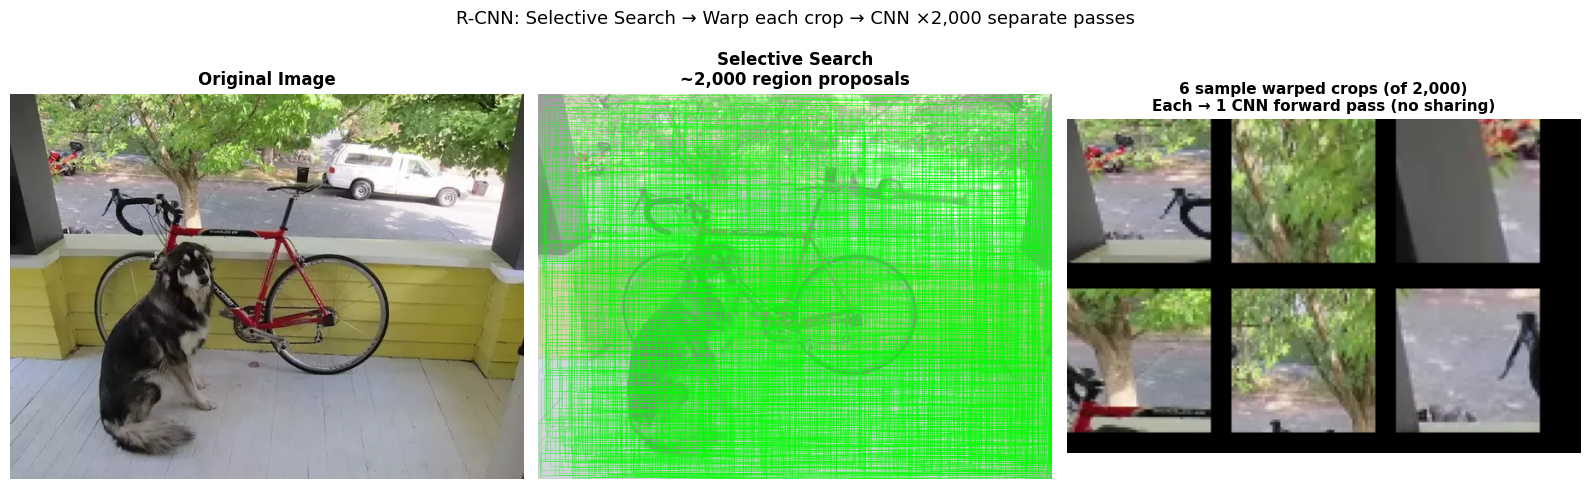

Bottleneck: 2,000 CNN passes per image → ~47 sec/image


In [3]:
# ── R-CNN: Visualize Selective Search proposals ───────────────────────────────
img_bgr = cv2.imread('dog-cycle-car.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

# Simulate Selective Search: ~2,000 candidate boxes of varying size/position
# Real Selective Search merges similar pixels hierarchically
np.random.seed(42)
n_proposals = 2000
proposals = []
for _ in range(n_proposals):
    x = np.random.randint(0, W - 20)
    y = np.random.randint(0, H - 20)
    w = np.random.randint(20, min(W - x, 200))
    h = np.random.randint(20, min(H - y, 200))
    proposals.append((x, y, w, h))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: original image
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel 2: all ~2,000 Selective Search proposals
axes[1].imshow(img_rgb, alpha=0.5)
for (x, y, w, h) in proposals:
    rect = patches.Rectangle((x, y), w, h,
                              linewidth=0.4, edgecolor='lime', facecolor='none', alpha=0.5)
    axes[1].add_patch(rect)
axes[1].set_title(f'Selective Search\n~{n_proposals:,} region proposals', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Panel 3: 6 sample warped crops — what each CNN forward pass actually sees
sample_props = [(30,40,120,150),(150,10,100,80),
                (10,80,60,60),  (180,60,90,120),
                (80,20,140,100),(50,100,80,70)]
grid = np.zeros((2*60+10, 3*60+20, 3), dtype=np.uint8)
for idx, (x, y, w, h) in enumerate(sample_props):
    x2, y2 = min(x+w, W), min(y+h, H)
    crop = img_rgb[y:y2, x:x2]
    if crop.size == 0: continue
    warped = cv2.resize(crop, (56, 56))
    row, col = idx // 3, idx % 3
    grid[row*66:row*66+56, col*64:col*64+56] = warped

axes[2].imshow(grid)
axes[2].set_title(f'6 sample warped crops (of {n_proposals:,})\nEach → 1 CNN forward pass (no sharing)', fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.suptitle('R-CNN: Selective Search → Warp each crop → CNN ×2,000 separate passes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(f"Bottleneck: {n_proposals:,} CNN passes per image → ~47 sec/image")


## 1.2 Fast R-CNN (2015)

**Paper:** Girshick, *Fast R-CNN*, ICCV 2015

Fast R-CNN fixed the speed problem by running the CNN **once** on the whole image and extracting features for each region from the shared feature map.

### How it works

<img src="img/fast_rcnn.png" title="Fast R-CNN Architecture" style="width: 800px;" />

```
Input Image
    ↓
CNN backbone (VGG16) → shared feature map
    ↑
Selective Search → ~2,000 region proposals (on original image)
    ↓
RoI Pooling → fixed 7×7 feature grid (per proposal)
    ↓
FC layers → [class scores (softmax)]  +  [bbox offsets]   (jointly trained)
```

### RoI Pooling

<img src="img/roi_pooling.png" title="ROI Pooling" style="width: 700px;" />

Each region proposal maps to a sub-region of the feature map. RoI Pooling divides that sub-region into a fixed $H \times W$ grid and max-pools each cell — allowing proposals of any size to produce a fixed-length feature vector.

### Multi-task Loss

Fast R-CNN is the first detector trained **end-to-end** with a single joint loss:

$$\mathcal{L}(p, u, t^u, v) = \underbrace{\mathcal{L}_{\text{cls}}(p, u)}_{\text{classification}} + \lambda \cdot \underbrace{\mathbf{1}[u \geq 1] \cdot \mathcal{L}_{\text{loc}}(t^u, v)}_{\text{box regression (foreground only)}}$$

**Classification loss** — cross-entropy over $K+1$ classes (K objects + background):
$$\mathcal{L}_{\text{cls}}(p, u) = -\log p_u$$
where $p_u$ is the predicted probability for the true class $u$.

**Localisation loss** — smooth L1 (Huber loss) on box offsets, applied **only to foreground proposals** ($u \geq 1$, i.e. not background):
$$\mathcal{L}_{\text{loc}}(t^u, v) = \sum_{i \in \{x,y,w,h\}} \text{smooth}_{L1}(t^u_i - v_i)$$

$$\text{smooth}_{L1}(x) = \begin{cases} 0.5x^2 & |x| < 1 \\ |x| - 0.5 & \text{otherwise} \end{cases}$$

> Smooth L1 is more robust than MSE — it's quadratic for small errors (well-behaved gradients) and linear for large errors (less sensitive to outliers). R-CNN used plain MSE.

Why $\mathbf{1}[u \geq 1]$? Background proposals have no ground truth box, so there's nothing to regress — we skip the loc loss for them.

### Improvement over R-CNN
- **9× faster** training, **213× faster** testing (one CNN pass instead of 2,000)
- **End-to-end** training — all losses backprop through shared feature map jointly
- Replaces SVM + separate bbox regressor with a single multi-task loss
- Still bottlenecked by **Selective Search** (CPU-based, ~2 sec/image)


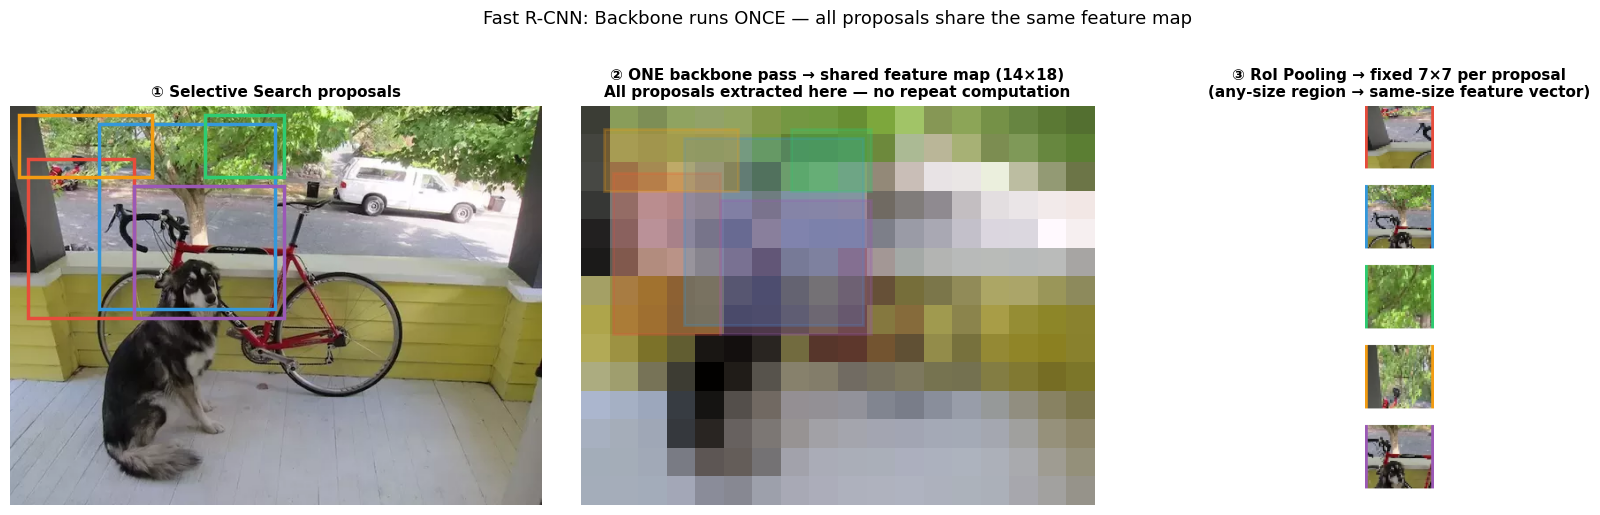

1 backbone pass + 5 RoI Pools — instead of 5 separate CNN passes
Bottleneck shifts from CNN → Selective Search (~2s CPU)


In [4]:
# ── Fast R-CNN: Shared feature map + RoI Pooling ──────────────────────────────
img_bgr = cv2.imread('dog-cycle-car.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

stride = 32
Hf, Wf = H // stride, W // stride

# Simulate backbone: 1 forward pass → feature map
img_t    = torch.tensor(img_rgb, dtype=torch.float32).permute(2,0,1).unsqueeze(0) / 255.
feat_map = F.avg_pool2d(img_t, kernel_size=stride, stride=stride)   # (1,3,Hf,Wf)
feat_vis = feat_map[0].permute(1,2,0).numpy()
feat_vis = (feat_vis - feat_vis.min()) / (feat_vis.max() - feat_vis.min())

# 5 example proposals (x1,y1,x2,y2)
proposals = [(20,60,140,240),(100,20,300,230),(220,10,310,80),(10,10,160,80),(140,90,310,240)]
colors    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: proposals on original image
axes[0].imshow(img_rgb)
for (x1,y1,x2,y2), c in zip(proposals, colors):
    axes[0].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                      linewidth=2.5, edgecolor=c, facecolor='none'))
axes[0].set_title('① Selective Search proposals', fontsize=11, fontweight='bold')
axes[0].axis('off')

# Panel 2: ONE shared feature map — all proposals projected here
axes[1].imshow(feat_vis)
for (x1,y1,x2,y2), c in zip(proposals, colors):
    fx1,fy1 = x1/stride, y1/stride
    fw,  fh = (x2-x1)/stride, (y2-y1)/stride
    axes[1].add_patch(patches.Rectangle((fx1,fy1),fw,fh,
                      linewidth=2, edgecolor=c, facecolor=c, alpha=0.25))
axes[1].set_title(f'② ONE backbone pass → shared feature map ({Hf}×{Wf})\nAll proposals extracted here — no repeat computation', fontsize=11, fontweight='bold')
axes[1].axis('off')

# Panel 3: RoI Pool output for each proposal (7×7 fixed size)
roi_grid = np.ones((len(proposals)*58, 50, 3))
for idx, ((x1,y1,x2,y2), c) in enumerate(zip(proposals, colors)):
    crop = img_rgb[y1:y2, x1:x2]
    if crop.size == 0: continue
    roi_big = cv2.resize(crop, (46, 46))
    ry = idx * 58
    roi_grid[ry:ry+46, 2:48] = roi_big / 255.
    color_rgb = tuple(int(c.lstrip('#')[i:i+2],16)/255. for i in (0,2,4))
    roi_grid[ry:ry+46, :2]  = color_rgb
    roi_grid[ry:ry+46, 48:] = color_rgb

axes[2].imshow(roi_grid)
axes[2].set_title('③ RoI Pooling → fixed 7×7 per proposal\n(any-size region → same-size feature vector)', fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Fast R-CNN: Backbone runs ONCE — all proposals share the same feature map', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print("1 backbone pass + 5 RoI Pools — instead of 5 separate CNN passes")
print("Bottleneck shifts from CNN → Selective Search (~2s CPU)")


## 1.3 Faster R-CNN (2016)

**Paper:** Ren et al., *Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks*, NeurIPS 2015

Faster R-CNN replaced Selective Search with a learned **Region Proposal Network (RPN)** that shares the same backbone as the detection head.

### How it works

<img src="img/faster_rcnn.png" title="Faster R-CNN Architecture" style="width: 800px;" />

```
Input Image
    ↓
CNN backbone → shared feature map
    ├── RPN → objectness scores + bbox proposals  (on same feature map)
    └── RoI Pooling (on RPN proposals)
            ↓
        FC layers → class + refined bbox
```

### Region Proposal Network (RPN)

A small network slides a 3×3 window over every feature map location. At each location it considers $k=9$ **anchor boxes** (3 scales × 3 aspect ratios) and predicts:
- **Objectness score**: is there an object here? (binary)
- **4 bbox offsets**: $(t_x, t_y, t_w, t_h)$ relative to the anchor

With a 56×56 feature map: $56 \times 56 \times 9 = 28{,}224$ anchors — all scored in one forward pass.

An anchor is **positive** if IoU > 0.7 with any GT box, **negative** if IoU < 0.3. Anchors between 0.3–0.7 are ignored during training.

### Loss Functions

Faster R-CNN has **two losses trained jointly** (4 loss terms total):

**RPN loss** — trains the proposal network:
$$\mathcal{L}_{\text{RPN}} = \frac{1}{N_{\text{cls}}} \sum_i \mathcal{L}_{\text{cls}}(p_i, p_i^*) + \lambda \frac{1}{N_{\text{reg}}} \sum_i p_i^* \cdot \mathcal{L}_{\text{reg}}(t_i, t_i^*)$$

- $p_i$ = predicted objectness score for anchor $i$; $p_i^* = 1$ if positive anchor, 0 if negative
- $\mathcal{L}_{\text{cls}}$ = binary cross-entropy (object vs background)
- $\mathcal{L}_{\text{reg}}$ = smooth L1 on offsets $(t_x, t_y, t_w, t_h)$, only for positive anchors ($p_i^* = 1$)

**Detection head loss** — same multi-task loss as Fast R-CNN:
$$\mathcal{L}_{\text{det}} = \mathcal{L}_{\text{cls}}(p, u) + \lambda \cdot \mathbf{1}[u \geq 1] \cdot \mathcal{L}_{\text{loc}}(t^u, v)$$

- $\mathcal{L}_{\text{cls}}$ = cross-entropy over $K+1$ classes
- $\mathcal{L}_{\text{loc}}$ = smooth L1 on refined box offsets, foreground only

**Total loss:**
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{RPN}} + \mathcal{L}_{\text{det}}$$

The backbone is shared — gradients from both losses flow back through the same feature extractor simultaneously.

### Speed comparison

| Model | Proposal method | Speed | Loss |
|---|---|---|---|
| R-CNN | Selective Search + 2000× CNN | ~47 s/img | 3 separate losses, not joint |
| Fast R-CNN | Selective Search + 1× CNN | ~2 s/img | 1 joint loss (cls + smooth L1) |
| Faster R-CNN | RPN on GPU (~10 ms) | ~0.2 s/img | 2 joint losses (RPN + det head) |

### Improvement over Fast R-CNN
- Proposal generation: ~10ms (GPU) vs ~2s (CPU Selective Search)
- Truly end-to-end: backbone, RPN, and detection head trained jointly
- Still a **two-stage** detector: RPN → RoI classification


Total anchors: 14×18 locations × 9 shapes = 2,268


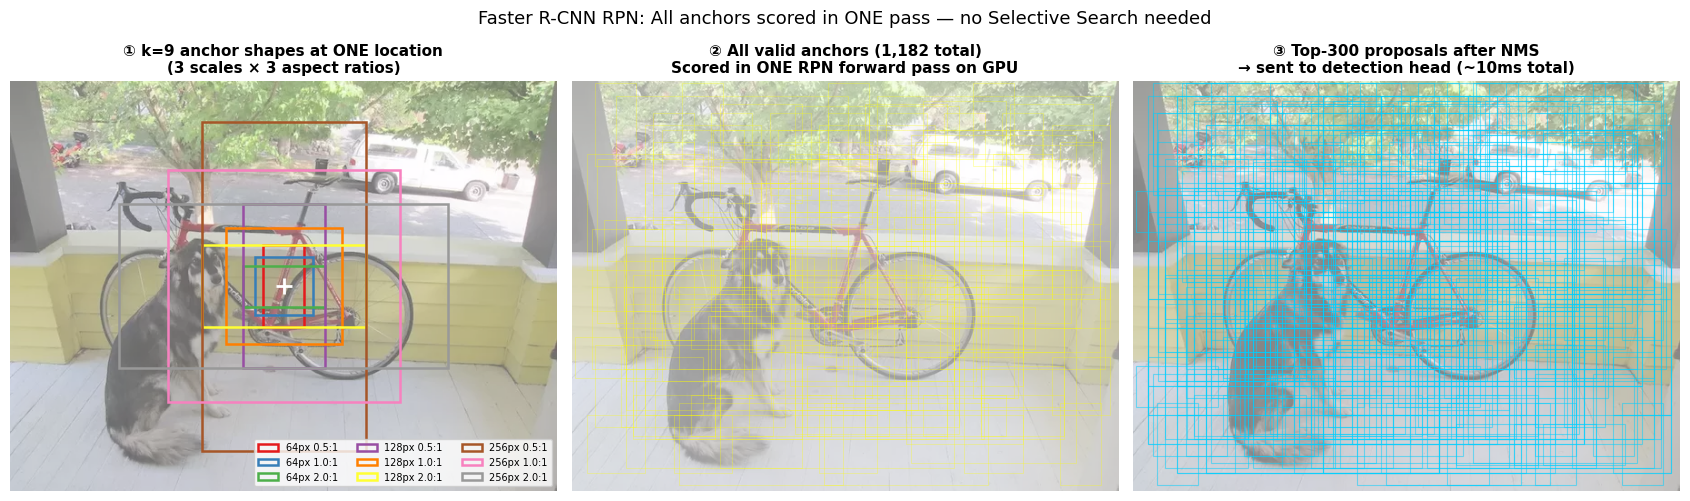

RPN: 2,268 anchors → scored in 1 pass → top 300 → detection head
Selective Search: ~2,000ms CPU | RPN: ~10ms GPU  →  200× speedup


In [5]:
# ── Faster R-CNN: RPN anchor visualization ────────────────────────────────────
img_bgr = cv2.imread('dog-cycle-car.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

stride = 32
Hf, Wf = H // stride, W // stride

# Generate all anchors (3 scales × 3 ratios = 9 per location)
scales = [64, 128, 256]
ratios = [0.5, 1.0, 2.0]
anchors = []
for cy in range(Hf):
    for cx in range(Wf):
        ctr_x = (cx + 0.5) * stride
        ctr_y = (cy + 0.5) * stride
        for s in scales:
            for r in ratios:
                aw = s * (r ** 0.5)
                ah = s / (r ** 0.5)
                anchors.append((ctr_x-aw/2, ctr_y-ah/2, ctr_x+aw/2, ctr_y+ah/2))
anchors = np.array(anchors)
print(f"Total anchors: {Hf}×{Wf} locations × 9 shapes = {len(anchors):,}")

# Valid anchors: center inside image
valid = anchors[
    (anchors[:,0] > 0) & (anchors[:,1] > 0) &
    (anchors[:,2] < W) & (anchors[:,3] < H)
]

# Top-300 proposals (simulated — RPN scores then NMS)
np.random.seed(7)
top_300 = valid[np.random.choice(len(valid), size=min(300,len(valid)), replace=False)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: 9 anchor shapes at ONE location
axes[0].imshow(img_rgb, alpha=0.6)
cx_d, cy_d = W//2, H//2
demo_colors = plt.cm.Set1(np.linspace(0,1,9))
for i, (s,r) in enumerate([(s,r) for s in scales for r in ratios]):
    aw = s*(r**0.5); ah = s/(r**0.5)
    axes[0].add_patch(patches.Rectangle(
        (cx_d-aw/2, cy_d-ah/2), aw, ah,
        linewidth=1.8, edgecolor=demo_colors[i], facecolor='none',
        label=f'{s}px {r}:1'))
axes[0].plot(cx_d, cy_d, 'w+', markersize=12, markeredgewidth=2)
axes[0].set_title('① k=9 anchor shapes at ONE location\n(3 scales × 3 aspect ratios)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=7, loc='lower right', ncol=3)
axes[0].axis('off')

# Panel 2: all valid anchors across feature map (sampled for visibility)
axes[1].imshow(img_rgb, alpha=0.4)
for (x1,y1,x2,y2) in valid[::10]:
    axes[1].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                      linewidth=0.4, edgecolor='yellow', facecolor='none', alpha=0.5))
axes[1].set_title(f'② All valid anchors ({len(valid):,} total)\nScored in ONE RPN forward pass on GPU', fontsize=11, fontweight='bold')
axes[1].axis('off')

# Panel 3: top-300 proposals after NMS
axes[2].imshow(img_rgb, alpha=0.5)
for (x1,y1,x2,y2) in top_300:
    axes[2].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                      linewidth=0.8, edgecolor='#00cfff', facecolor='none', alpha=0.5))
axes[2].set_title(f'③ Top-300 proposals after NMS\n→ sent to detection head (~10ms total)', fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Faster R-CNN RPN: All anchors scored in ONE pass — no Selective Search needed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(f"RPN: {len(anchors):,} anchors → scored in 1 pass → top 300 → detection head")
print(f"Selective Search: ~2,000ms CPU | RPN: ~10ms GPU  →  200× speedup")


## 1.4 YOLO v1 (2016)

**Paper:** Redmon et al., *You Only Look Once: Unified, Real-Time Object Detection*, CVPR 2016

YOLO reframed detection as a **single regression problem**: one network pass from pixels to bounding boxes and class probabilities. No region proposals, no two stages.

### The Key Idea: Grid-based prediction

<img src="img/yolo_v1.png" title="YOLO v1" style="width: 800px;" />

Divide the image into an $S \times S$ grid (e.g., $7 \times 7$). Each grid cell predicts:
- $B$ bounding boxes (each with $x, y, w, h$, confidence)
- $C$ class probabilities

Total output tensor: $S \times S \times (B \times 5 + C)$ — e.g., $7 \times 7 \times 30$ for PASCAL VOC ($B=2$, $C=20$).

### Network Architecture

<img src="img/yolo_v1_arch.png" title="YOLO v1 Architecture" style="width: 900px;" />

24 convolutional layers followed by 2 fully connected layers. Input: 448×448. Output: 7×7×30.

### Confidence Score

Each bounding box outputs a **confidence score**:
$$\text{Confidence} = \Pr(\text{Object}) \times \text{IoU}_{\text{pred}}^{\text{truth}}$$

The final class-specific score:
$$\text{Class score} = \Pr(\text{Class}_i | \text{Object}) \times \Pr(\text{Object}) \times \text{IoU} = \Pr(\text{Class}_i) \times \text{IoU}$$

### YOLO v1 Loss Function

$$\mathcal{L} = \lambda_{coord} \sum_{i,j} \mathbf{1}_{ij}^{obj} \left[(x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2\right]$$
$$+ \lambda_{coord} \sum_{i,j} \mathbf{1}_{ij}^{obj} \left[(\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2\right]$$
$$+ \sum_{i,j} \mathbf{1}_{ij}^{obj} (C_i - \hat{C}_i)^2 + \lambda_{noobj} \sum_{i,j} \mathbf{1}_{ij}^{noobj} (C_i - \hat{C}_i)^2$$
$$+ \sum_{i} \mathbf{1}_{i}^{obj} \sum_{c} (p_i(c) - \hat{p}_i(c))^2$$

**Note**: $\sqrt{w}, \sqrt{h}$ penalizes errors in small boxes more than large boxes.

### Limitations of YOLO v1
- Each cell predicts only **1 class** → struggles with overlapping objects
- Struggles with **small objects** (coarse 7×7 grid)
- Lower localization accuracy vs Faster R-CNN

### What YOLO v3 improved
- **Multi-scale** detection at 3 grid sizes (13×13, 26×26, 52×52)
- **Darknet-53** backbone with residual connections
- **9 anchor boxes** (3 per scale) chosen by k-means on training data
- **Independent logistic classifiers** → supports multi-label detection


## 1.5 YOLO v3 (2018)

Now let's look at YOLO v3 in detail and build it in PyTorch.

<img src="img/yolo05.png" title="GroundTruthBox" style="width: 400px;" />

The grid is represented by the black lines. The ground truth bounding box for the object is the yellow rectangle. The center
of this bounding box happens to be within the red-outlined grid cell.

The grid cell containing the center of a ground truth bounding box is given the responsibility during training to try to predict
the presence of the object.

In order to indicate the presence of the given object, the model outputs several parameters for a given candidate object:
 - $(t_x, t_y, t_w, t_h)$ indicate the box's location and size. During training, the targets for these outputs are the actual ground truth box parameters.
 - $p_o$ is an "objectness" score that indicates the likelihood that an object exists in the given bounding box. This output uses a sigmoid function.
   During training, the target for $p_o$ is set to 1 for the center grid cell (the red grid cell), and it is set to 0 for the the neighboring grid cells.
 - $(p_1, p_2, \ldots, p_n)$ are class confidence scores. They indicate the probability of the detected object belonging to a particular class. The targets,
   obviously, are set to 1 for the ground truth object class and 0 for other classes during training.

### Anchor Boxes

One problem that would occur in YOLO if you tried to directly learn the parameters mentioned above is the problem of unstable gradients during training.
In a way that is sort of analagous to how a residual block begins with an identity map and learns differences from identity, YOLO v3 uses the idea of
anchor boxes originally introduced by the R-CNN team. Instead of predicting $(t_x, t_y, t_w, t_h)$ directly, we predict how those parameters are *different from
the parameters of a typical bounding box, an anchor box*.
YOLO v3 uses three bounding boxes per cell. At training time, once ground truth bounding box's center is mapped to a grid cell, we find which of the anchors for
that cell has the highest IoU with the ground truth box.

### So What Does YOLO Actually Predict?

First, let's understand that all predictions are relative to the grid cell. YOLO predicts the following:
- Offsets $(t_x, t_y)$ are specified relative to the top left corner of the grid cell, as a ratio between 0 and 1, using a sigmoid to limit the values.
- Height, and width $(t_w, t_h)$ are specified relative to the dimensions of an anchor box.

Thus, YOLO does not predict absolute coordinates -- it predicts values that can then be used to compute the box's position and size in absolute coordinates.
This diagram gives the idea. We see that the absolute $t_x$ is the grid cell's $(c_x, c_y)$ plus $\sigma(t_x)$ times the grid cell width. Similarly for $t_y$.
The absolute width of the predicted bounding box is the width of the anchor box times $e^{tw}$. Similarly for the height.

<img src="img/yolo06.png" title="GroundTruthBox" style="width: 640px;" />

Hopefully you can see the difference between the YOLO v3 bounding box predictions and the Faster R-CNN bounding box predictions. The offset of the center is
encoded relative to the grid cell containing the anchor box rather than the anchor box itself. The dimensions of the bounding box, however, similar to Faster R-CNN,
are predicted relative to the anchor box size.

### Multi-scale prediction

Rather than a single grid size and grid cell size,
YOLO v3 detects objects at multiple sizes with downsampling factors of 32, 16, and 8. The largest objects are detected at the
first, coarsest scale, whereas mid-sized objects are detected at the intermediate scale, and small objects are detected at the finest
scale. The example below shows the three grid sizes relative to the image and an object:

<img src="img/yolo_Scales.png" title="GroundTruthBox" style="width: 640px;" />

### YOLO dataset format

A YOLO dataset contains two sets of files, each pair with the same name: image files (in any supported format)
and label files (in TXT, JSON, or XML format). A label file contains data in the format

$$i, C_x, C_y, L_x, L_y$$

- $i$: Label index
- $C_x$: Center position in the horizontal ($x$-axis) direction, encoded in the range 0-1, where 0 means the left edge of the image and 1 means the right edge.
- $C_y$: Center position in the vertical ($y$-axis) direction, encoded in the range 0-1, where 0 means the top edge of the image and 1 means the bottom edge.
- $L_x$: Object width, encoded in the range 0-1, where 1 means the width of the image.
- $L_y$: Object height, encoded in the range 0-1, where 1 means the height of the image.

To calculate these values for an object, suppose $(W,H)$ is the actual size of a particular image in pixels,
$(O_x, O_y)$ is the actual position of an object in that image, in pixels, and $(l_x,l_y)$ is the actual size of the object, again in pixels.
The object label elements would be calculated as

$$C_x = \frac{O_x}{W}, \; C_y = \frac{O_y}{H} \\
L_x = \frac{l_x}{W}, \; L_y = \frac{l_y}{H}$$

### YOLOv3 Architecture

<img src="img/YOLOv3_Architecture.png" title="YOLOv3" style="width: 960px;" />

### Preparation for Building YOLO in PyTorch

First of all, we will need OpenCV:

    pip3 install --upgrade pip
    pip install matplotlib opencv-python

Create a directory where the code for your detector will live.

In that directory, download util.py and darknet.py from https://github.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch.

In Jupyter you would download thusly:

In [6]:
import os
if not os.path.exists('darknet.py'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/darknet.py')
if not os.path.exists('util.py'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/util.py')
print('darknet.py:', 'OK' if os.path.exists('darknet.py') else 'MISSING')
print('util.py   :', 'OK' if os.path.exists('util.py') else 'MISSING')


darknet.py: OK
util.py   : OK


If you're in a Docker container, just run the `wget` commands at the command line. Make sure your proxy environment variables are set correctly.

### Take a Look at the YOLO Darknet Configuration File

Next, let's download the `yolov3.cfg` configuration file and take a look. You could grab it from the canonical Darknet github repository
or any other place it's stored.

In [7]:
import os
os.makedirs('cfg', exist_ok=True)
if not os.path.exists('cfg/yolov3.cfg'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/cfg/yolov3.cfg -O cfg/yolov3.cfg')
print('cfg/yolov3.cfg:', 'OK' if os.path.exists('cfg/yolov3.cfg') else 'MISSING')


cfg/yolov3.cfg: OK


The configuration file looks like this:

    [net]
    # Testing
    batch=1
    subdivisions=1
    # Training
    # batch=64
    # subdivisions=16
    width= 416

    height = 416
    channels=3
    momentum=0.9
    decay=0.0005
    angle=0
    saturation = 1.5
    exposure = 1.5
    hue=.1

    learning_rate=0.001
    burn_in=1000
    max_batches = 500200
    policy=steps
    steps=400000,450000
    scales=.1,.1

    [convolutional]
    batch_normalize=1
    filters=32
    size=3
    stride=1
    pad=1
    activation=leaky

    ...

    [shortcut]
    from=-3
    activation=linear

    ...

    [yolo]
    mask = 6,7,8
    anchors = 10,13,  16,30,  33,23,  30,61,  62,45,  59,119,  116,90,  156,198,  373,326
    classes=80
    num=9
    jitter=.3
    ignore_thresh = .7
    truth_thresh = 1
    random=1

    [route]
    layers = -4

    [convolutional]
    batch_normalize=1
    filters=256
    size=1
    stride=1
    pad=1
    activation=leaky

    [upsample]
    stride=2

    [route]
    layers = -1, 61

    ...



### Overview of the Configuration Blocks

The configuration blocks fall into a few cateogies:

- Net: the global configuration at the top of the configuration file. It declares the size of input images, batch size, learning rate, and so on.

      batch=64
      subdivisions=16
      width=608
      height=608
      channels=3
      momentum=0.9
      decay=0.0005
      angle=0
      saturation = 1.5
      exposure = 1.5
      hue=.1


- Convolutional: convolutional layer. Note that this specfication is a little more powerful than the PyTorch way of doing things, as options
  for batch normalization and the activation function (leaky ReLU in this case) are built in.
 
      [convolutional]
      batch_normalize=1
      filters=32
      size=3
      stride=1
      pad=1
      activation=leaky
        

- Shortcut: skip connections that implement residual blocks. -3 means to add the feature maps output by the previous layer to those output by the layer three layers
  back. Linear activation means identity (no nonlinear activation of the result).
  
      [shortcut]
      from=-3           # Connect the layer three layers back to here.
      activation=linear


- Upsample: Bilinear upsampling of the previous layer using a particular stride

      [upsample]
      stride=2


- Route: The route layer deserves a bit of explanation. It has an attribute `layers`, which can have either one or two values.
  
      [route]
      layers = -4

      [route]
      layers = -1, 61    
  
  When the layers attribute has only one value, it outputs the feature maps of the layer indexed by the value. In our example, it is -4, so the layer will output
  the feature maps from the 4th layer backwards from the route layer.

  When layers has two values, it returns the concatenated feature maps of the layers indexed by its values. In our example it is -1, 61, so the layer will output
  feature maps from the previous layer (-1) and the 61st layer, concatenated along the channels (depth) dimension.
   
- YOLO:
 
      [yolo]
      mask = 0,1,2
      anchors = 10,13,  16,30,  33,23,  30,61,  62,45,  59,119,  116,90,  156,198,  373,326
      classes=80
      num=9
      jitter=.3
      ignore_thresh = .5
      truth_thresh = 1
      random=1
  
  Here we have a few important attributes:
  
  - anchors: describes the anchor boxes. The model contains 9 anchors, but only those in the `mask` are used.

  - mask: which anchor indices will be used in this YOLO layer
     
  - classes: number of object classes


### Create a network from the config file

We are going to follow the general approach of some of the GitHub contributors who have developed PyTorch tools
to deal with Darknet models. In the file `darknet.py`, there's a `parse_cfg` function. The function will read
the Darknet configuration file and store the blocks in a dictionary.

```python
file  = open(cfgfile, 'r')
lines = file.read().split('\n')          # store the lines in a list
lines = [x for x in lines if len(x) > 0] # get rid of empty lines
lines = [x for x in lines if x[0] != '#'] # get rid of comments
lines = [x.rstrip().lstrip() for x in lines] # get rid of fringe whitespaces

block  = {}
blocks = []

for line in lines:
    if line[0] == "[":              # marks the start of a new block
        if len(block) != 0:         # if block not empty, store previous block
            blocks.append(block)
            block = {}
        block["type"] = line[1:-1].rstrip()
    else:
        key, value = line.split("=")
        block[key.rstrip()] = value.lstrip()
blocks.append(block)
```


### Convolutional block

```python
# If it's a convolutional layer
if (x["type"] == "convolutional"):
    activation     = x["activation"]
    try:
        batch_normalize = int(x["batch_normalize"])
        bias = False
    except:
        batch_normalize = 0
        bias = True

    filters    = int(x["filters"])
    padding    = int(x["pad"])
    kernel_size = int(x["size"])
    stride     = int(x["stride"])

    pad = (kernel_size - 1) // 2 if padding else 0

    # Add the convolutional layer
    conv = nn.Conv2d(prev_filters, filters, kernel_size, stride, pad, bias=bias)
    module.add_module("conv_{0}".format(index), conv)

    # Add Batch Norm layer
    if batch_normalize:
        bn = nn.BatchNorm2d(filters)
        module.add_module("batch_norm_{0}".format(index), bn)

    # Activation: Linear or LeakyReLU for YOLO
    if activation == "leaky":
        activn = nn.LeakyReLU(0.1, inplace=True)
        module.add_module("leaky_{0}".format(index), activn)
```


### Shortcut block

The shortcut block corresponds to a **skip connection** (same idea as ResNet).

```python
# shortcut = skip connection
elif x["type"] == "shortcut":
    shortcut = EmptyLayer()
    module.add_module("shortcut_{}".format(index), shortcut)
```

`EmptyLayer` is a placeholder — the actual addition happens in `forward()` where we can access stored layer outputs by index.


### Upsample block

```python
# If it's an upsampling layer — use bilinear 2D upsampling
elif x["type"] == "upsample":
    stride   = int(x["stride"])
    upsample = nn.Upsample(scale_factor=2, mode="nearest")
    module.add_module("upsample_{}".format(index), upsample)
```


### Route block

The route layer **concatenates** feature maps from earlier layers. It uses `EmptyLayer` as a placeholder
because tensors don't exist yet at module-creation time — the actual concatenation happens in `forward()`.

```python
# If it's a route layer
elif x["type"] == "route":
    x["layers"] = x["layers"].split(',')
    start = int(x["layers"][0])
    try:
        end = int(x["layers"][1])
    except:
        end = 0

    # Convert relative indices to absolute
    if start > 0: start = start - index
    if end > 0:   end   = end   - index

    route = EmptyLayer()   # ← placeholder; concat done in forward()
    module.add_module("route_{}".format(index), route)

    if end < 0:
        filters = output_filters[index + start] + output_filters[index + end]
    else:
        filters = output_filters[index + start]
```


### YOLO block

The YOLO block is the **detection layer** — it stores the anchor boxes for that scale.

```python
# YOLO is the detection layer
elif x["type"] == "yolo":
    mask    = x["mask"].split(",")
    mask    = [int(x) for x in mask]

    anchors = x["anchors"].split(",")
    anchors = [int(a) for a in anchors]
    anchors = [(anchors[i], anchors[i+1]) for i in range(0, len(anchors), 2)]
    anchors = [anchors[i] for i in mask]   # keep only anchors for this scale

    detection = DetectionLayer(anchors)
    module.add_module("Detection_{}".format(index), detection)
```


### Using the code

OK, let's try it out. Depending on what you already have installed, you may need to run

    # apt install libgl1-mesa-glx

for the next step to run.

In [8]:
import darknet

blocks = darknet.parse_cfg("cfg/yolov3.cfg")
print(darknet.create_modules(blocks))

({'type': 'net', 'batch': '1', 'subdivisions': '1', 'width': '416', 'height': '416', 'channels': '3', 'momentum': '0.9', 'decay': '0.0005', 'angle': '0', 'saturation': '1.5', 'exposure': '1.5', 'hue': '.1', 'learning_rate': '0.001', 'burn_in': '1000', 'max_batches': '500200', 'policy': 'steps', 'steps': '400000,450000', 'scales': '.1,.1'}, ModuleList(
  (0): Sequential(
    (conv_0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (batch_norm_0): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (leaky_0): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (1): Sequential(
    (conv_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (batch_norm_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (leaky_1): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (2): Sequential(
    (conv_2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    

### Darknet class

Let's make our own version of the `Darknet` class in `darknet.py`.

The class has two main functions:

1. `forward()`: forward propagation, following the instructions in the dictionary modules
2. `load_weights()`: load a set of pretrained weights into the network


In [9]:
from util import *

class MyDarknet(nn.Module):
    def __init__(self, cfgfile):
        super(MyDarknet, self).__init__()
        # load the config file and create our model
        self.blocks = darknet.parse_cfg(cfgfile)
        self.net_info, self.module_list = darknet.create_modules(self.blocks)
        
    def forward(self, x, CUDA:bool):
        modules = self.blocks[1:]
        outputs = {}   #We cache the outputs for the route layer
        
        write = 0
        # run forward propagation. Follow the instruction from dictionary modules
        for i, module in enumerate(modules):        
            module_type = (module["type"])
            
            if module_type == "convolutional" or module_type == "upsample":
                # do convolutional network
                x = self.module_list[i](x)
    
            elif module_type == "route":
                # concat layers
                layers = module["layers"]
                layers = [int(a) for a in layers]
    
                if (layers[0]) > 0:
                    layers[0] = layers[0] - i
    
                if len(layers) == 1:
                    x = outputs[i + (layers[0])]
    
                else:
                    if (layers[1]) > 0:
                        layers[1] = layers[1] - i
    
                    map1 = outputs[i + layers[0]]
                    map2 = outputs[i + layers[1]]
                    x = torch.cat((map1, map2), 1)
                
    
            elif  module_type == "shortcut":
                from_ = int(module["from"])
                # residual network
                x = outputs[i-1] + outputs[i+from_]
    
            elif module_type == 'yolo':        
                anchors = self.module_list[i][0].anchors
                #Get the input dimensions
                inp_dim = int (self.net_info["height"])
        
                #Get the number of classes
                num_classes = int (module["classes"])
        
                #Transform 
                # predict_transform is in util.py
                batch_size = x.size(0)
                stride =  inp_dim // x.size(2)
                grid_size = inp_dim // stride
                bbox_attrs = 5 + num_classes
                num_anchors = len(anchors)
                
                x = predict_transform(x, inp_dim, anchors, num_classes, CUDA)
                if not write:              #if no collector has been intialised. 
                    detections = x
                    write = 1
        
                else:       
                    detections = torch.cat((detections, x), 1)
        
            outputs[i] = x
        
        return detections


    def load_weights(self, weightfile):
        '''
        Load pretrained weight
        '''
        #Open the weights file
        fp = open(weightfile, "rb")
    
        #The first 5 values are header information 
        # 1. Major version number
        # 2. Minor Version Number
        # 3. Subversion number 
        # 4,5. Images seen by the network (during training)
        header = np.fromfile(fp, dtype = np.int32, count = 5)
        self.header = torch.from_numpy(header)
        self.seen = self.header[3]   
        
        weights = np.fromfile(fp, dtype = np.float32)
        
        ptr = 0
        for i in range(len(self.module_list)):
            module_type = self.blocks[i + 1]["type"]
    
            #If module_type is convolutional load weights
            #Otherwise ignore.
            
            if module_type == "convolutional":
                model = self.module_list[i]
                try:
                    batch_normalize = int(self.blocks[i+1]["batch_normalize"])
                except:
                    batch_normalize = 0
            
                conv = model[0]
                
                
                if (batch_normalize):
                    bn = model[1]
        
                    #Get the number of weights of Batch Norm Layer
                    num_bn_biases = bn.bias.numel()
        
                    #Load the weights
                    bn_biases = torch.from_numpy(weights[ptr:ptr + num_bn_biases])
                    ptr += num_bn_biases
        
                    bn_weights = torch.from_numpy(weights[ptr: ptr + num_bn_biases])
                    ptr  += num_bn_biases
        
                    bn_running_mean = torch.from_numpy(weights[ptr: ptr + num_bn_biases])
                    ptr  += num_bn_biases
        
                    bn_running_var = torch.from_numpy(weights[ptr: ptr + num_bn_biases])
                    ptr  += num_bn_biases
        
                    #Cast the loaded weights into dims of model weights. 
                    bn_biases = bn_biases.view_as(bn.bias.data)
                    bn_weights = bn_weights.view_as(bn.weight.data)
                    bn_running_mean = bn_running_mean.view_as(bn.running_mean)
                    bn_running_var = bn_running_var.view_as(bn.running_var)
        
                    #Copy the data to model
                    bn.bias.data.copy_(bn_biases)
                    bn.weight.data.copy_(bn_weights)
                    bn.running_mean.copy_(bn_running_mean)
                    bn.running_var.copy_(bn_running_var)
                
                else:
                    #Number of biases
                    num_biases = conv.bias.numel()
                
                    #Load the weights
                    conv_biases = torch.from_numpy(weights[ptr: ptr + num_biases])
                    ptr = ptr + num_biases
                
                    #reshape the loaded weights according to the dims of the model weights
                    conv_biases = conv_biases.view_as(conv.bias.data)
                
                    #Finally copy the data
                    conv.bias.data.copy_(conv_biases)
                    
                #Let us load the weights for the Convolutional layers
                num_weights = conv.weight.numel()
                
                #Do the same as above for weights
                conv_weights = torch.from_numpy(weights[ptr:ptr+num_weights])
                ptr = ptr + num_weights
                
                conv_weights = conv_weights.view_as(conv.weight.data)
                conv.weight.data.copy_(conv_weights)


### Test Forward Propagation

Let's propagate a single image through the network and see what we get.

In [10]:
import os
if not os.path.exists('dog-cycle-car.png'):
    os.system('wget -q https://github.com/ayooshkathuria/pytorch-yolo-v3/raw/master/dog-cycle-car.png')
print('dog-cycle-car.png:', 'OK' if os.path.exists('dog-cycle-car.png') else 'MISSING')


dog-cycle-car.png: OK


Here's code to load the image into memory and push it through the model:

In [11]:
import cv2
import torch

def get_test_input():
    img = cv2.imread("dog-cycle-car.png")
    img = cv2.resize(img, (416,416))          #Resize to the input dimension
    img_ =  img[:,:,::-1].transpose((2,0,1))  # BGR -> RGB | H X W C -> C X H X W 
    img_ = img_[np.newaxis,:,:,:]/255.0       #Add a channel at 0 (for batch) | Normalise
    img_ = torch.from_numpy(img_).float()     #Convert to float
    img_ = Variable(img_)                     # Convert to Variable
    return img_

Go ahead and try it (noting that the model hasn't been trained so we don't expect any correct result):

In [12]:
from util import *

model = MyDarknet("cfg/yolov3.cfg")
inp = get_test_input()
pred = model(inp, False)
print (pred)

tensor([[[1.4705e+01, 1.9948e+01, 1.1583e+02,  ..., 3.8195e-01,
          6.0170e-01, 6.1023e-01],
         [1.4232e+01, 1.7154e+01, 1.0889e+02,  ..., 4.4937e-01,
          5.3535e-01, 4.4320e-01],
         [1.9576e+01, 1.7143e+01, 5.7654e+02,  ..., 4.3685e-01,
          5.3085e-01, 4.5428e-01],
         ...,
         [4.1177e+02, 4.1236e+02, 1.0514e+01,  ..., 4.4923e-01,
          4.9879e-01, 4.4218e-01],
         [4.1233e+02, 4.1134e+02, 1.4358e+01,  ..., 4.9147e-01,
          4.2182e-01, 4.1576e-01],
         [4.1216e+02, 4.1218e+02, 4.9025e+01,  ..., 5.8931e-01,
          4.9665e-01, 5.1157e-01]]], grad_fn=<CatBackward0>)


In [13]:
print(pred.shape)

torch.Size([1, 10647, 85])


### Understanding the output result

The result from prediction model will be $B(13\cdot 13 + 26\cdot 26 + 52 \cdot 52)3\cdot85$. Why? We have
- $B$: the number of images in the batch
- $13\cdot 13$: number of elements (grid cells) in the coarsest feature map
- $26\cdot 16$: number of elements (grid cells) in the medium scale feature map
- $52\cdot 52$: number of elements (grid cells) in the finest cale feature map
- $3$: the number of anchor boxes per grid cell
- $85$: number of bounding box attributes (4 for bounding box, 1 for objectness, 80 for the COCO classes)

### Download a pretrained weight file

Darknet stores weights as in this diagram:

<img src="img/weights.png" title="weight" style="width: 600px;" />

In [14]:
import os
if not os.path.exists('yolov3.weights'):
    print('Downloading yolov3.weights (~237MB)...')
    os.system('wget https://pjreddie.com/media/files/yolov3.weights')
else:
    print('yolov3.weights already exists — skipping download')


yolov3.weights already exists — skipping download


You can download the yolov3 weights from [here](https://drive.google.com/file/d/1T_rTXbBx8pO-2UeehUSP4R3UN7vGqcAG/view?usp=sharing)

In [15]:
import os
if not os.path.exists("yolov3.weights"):
    raise FileNotFoundError(
        "yolov3.weights not found. Run the wget cell above first:\n"
        "  !wget https://pjreddie.com/media/files/yolov3.weights\n"
        "Or download from Google Drive: "
        "https://drive.google.com/file/d/1T_rTXbBx8pO-2UeehUSP4R3UN7vGqcAG"
    )
model.load_weights("yolov3.weights")


### Test with the sample image again

In [16]:
inp = get_test_input()
pred = model(inp, False)
print (pred)

tensor([[[8.5426e+00, 1.9015e+01, 1.1130e+02,  ..., 1.7306e-03,
          1.3874e-03, 9.2985e-04],
         [1.4105e+01, 1.8867e+01, 9.4014e+01,  ..., 5.9501e-04,
          9.2471e-04, 1.3085e-03],
         [2.1125e+01, 1.5269e+01, 3.5793e+02,  ..., 8.3609e-03,
          5.1068e-03, 5.8562e-03],
         ...,
         [4.1268e+02, 4.1069e+02, 3.7157e+00,  ..., 1.7186e-06,
          4.0955e-06, 6.5897e-07],
         [4.1132e+02, 4.1023e+02, 8.0353e+00,  ..., 1.3927e-05,
          3.2252e-05, 1.2076e-05],
         [4.1076e+02, 4.1318e+02, 4.9635e+01,  ..., 4.2175e-06,
          1.0794e-05, 1.8104e-05]]], grad_fn=<CatBackward0>)


### From YOLO output tensor to *true* detections

In the prediction result, there are many results. We need to threshold them using the objectness score
output for each bounding box prediction. The `write_results` function in `util.py` does just that.

    def write_results(prediction, confidence, num_classes, nms_conf = 0.4)

- prediction: prediction result tensor returned from the YOLO model
- confidence: objectness score threshold to apply to the set of detections
- num_classes: number of classes to expect
- nms_conf: NMS IoU threshold

NMS stands for "non-maxima suppression." The basic idea is that if you have two predicted bounding
boxes that overlap each other significantly, you should throw away the box with the lower confidence
score. Overlap is measured by IoU (Intersection over Union), wich is just the ratio of the the area
of intersection of the two regions with the area of the union of the two regions:

$$ IoU(R_1,R_2) = \frac{|R_1 \cap R_2|}{|R_1 \cup R_2|}. $$

The default of 0.4 means if the intersection is 40% or more of the union, the two bounding boxes
are overlapping enough that only one of the detections should survive.

In [17]:
write_results(pred.detach(), 0.5, 80, nms_conf = 0.4)

tensor([[  0.0000,  61.5403, 100.8597, 307.2717, 303.1133,   0.9469,   0.9985,
           1.0000],
        [  0.0000, 253.8484,  66.1096, 378.0395, 118.0089,   0.9992,   0.8164,
           7.0000],
        [  0.0000,  71.0338, 163.2243, 175.7471, 382.2702,   0.9999,   0.9936,
          16.0000]])

### Show the resulting detections on top of an image

The model was trained on the COCO dataset, so download the class label file `coco.names`:

In [18]:
import os
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/coco.names'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/data/coco.names -O data/coco.names')
print('data/coco.names:', 'OK' if os.path.exists('data/coco.names') else 'MISSING')


data/coco.names: OK


In [19]:
def load_classes(namesfile):
    fp = open(namesfile, "r")
    names = fp.read().split("\n")[:-1]
    return names

In [20]:
num_classes = 80
classes = load_classes("data/coco.names")
print(classes)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


So we see that the three surviving bounding boxes above, outputting object types 1, 7, and 16, indicate a bicycle, a truck, and a dog.
Let's draw the detections on top of the input image for better visualization.

We'll use some code based on Kathuria's `detect.py`. You can download the original as

In [21]:
import os
if not os.path.exists('detect.py'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/detect.py')
print('detect.py:', 'OK' if os.path.exists('detect.py') else 'MISSING')


detect.py: OK


Here's our version. It will process the images in subdirectory `cocoimages` so let's make it and put our sample there:

In [22]:
!mkdir -p cocoimages
!cp dog-cycle-car.png cocoimages/

In [23]:
from __future__ import division
import time
import torch 
import torch.nn as nn
from torch.autograd import Variable
import numpy as np
import cv2 
from util import *
import argparse
import os 
import os.path as osp
from darknet import Darknet
import pickle as pkl
import pandas as pd
import random

images = "cocoimages"
batch_size = 4
confidence = 0.5
nms_thesh = 0.4
start = 0
CUDA = torch.cuda.is_available()

num_classes = 80
classes = load_classes("data/coco.names")

#Set up the neural network

print("Loading network.....")
model = MyDarknet("cfg/yolov3.cfg")
model.load_weights("yolov3.weights")
print("Network successfully loaded")

model.net_info["height"] = 416
inp_dim = int(model.net_info["height"])
assert inp_dim % 32 == 0 
assert inp_dim > 32

#If there's a GPU availible, put the model on GPU

if CUDA:
    model.cuda()

# Set the model in evaluation mode

model.eval()

read_dir = time.time()

# Detection phase

try:
    imlist = [osp.join(osp.realpath('.'), images, img) for img in os.listdir(images)]
except NotADirectoryError:
    imlist = []
    imlist.append(osp.join(osp.realpath('.'), images))
except FileNotFoundError:
    print ("No file or directory with the name {}".format(images))
    exit()
    
if not os.path.exists("des"):
    os.makedirs("des")

load_batch = time.time()
loaded_ims = [cv2.imread(x) for x in imlist]

im_batches = list(map(prep_image, loaded_ims, [inp_dim for x in range(len(imlist))]))
im_dim_list = [(x.shape[1], x.shape[0]) for x in loaded_ims]
im_dim_list = torch.FloatTensor(im_dim_list).repeat(1,2)


leftover = 0
if (len(im_dim_list) % batch_size):
    leftover = 1

if batch_size != 1:
    num_batches = len(imlist) // batch_size + leftover            
    im_batches = [torch.cat((im_batches[i*batch_size : min((i +  1)*batch_size,
                        len(im_batches))]))  for i in range(num_batches)]  

write = 0

if CUDA:
    im_dim_list = im_dim_list.cuda()
    
start_det_loop = time.time()
for i, batch in enumerate(im_batches):
    # Load the image 
    start = time.time()
    if CUDA:
        batch = batch.cuda()
    with torch.no_grad():
        prediction = model(Variable(batch), CUDA)

    prediction = write_results(prediction, confidence, num_classes, nms_conf = nms_thesh)

    end = time.time()

    if type(prediction) == int:

        for im_num, image in enumerate(imlist[i*batch_size: min((i +  1)*batch_size, len(imlist))]):
            im_id = i*batch_size + im_num
            print("{0:20s} predicted in {1:6.3f} seconds".format(image.split("/")[-1], (end - start)/batch_size))
            print("{0:20s} {1:s}".format("Objects Detected:", ""))
            print("----------------------------------------------------------")
        continue

    prediction[:,0] += i*batch_size    #transform the atribute from index in batch to index in imlist 

    if not write:                      #If we have't initialised output
        output = prediction  
        write = 1
    else:
        output = torch.cat((output,prediction))

    for im_num, image in enumerate(imlist[i*batch_size: min((i +  1)*batch_size, len(imlist))]):
        im_id = i*batch_size + im_num
        objs = [classes[int(x[-1])] for x in output if int(x[0]) == im_id]
        print("{0:20s} predicted in {1:6.3f} seconds".format(image.split("/")[-1], (end - start)/batch_size))
        print("{0:20s} {1:s}".format("Objects Detected:", " ".join(objs)))
        print("----------------------------------------------------------")

    if CUDA:
        torch.cuda.synchronize()       
try:
    output
except NameError:
    print ("No detections were made")
    exit()

im_dim_list = torch.index_select(im_dim_list, 0, output[:,0].long())

scaling_factor = torch.min(416/im_dim_list,1)[0].view(-1,1)

output[:,[1,3]] -= (inp_dim - scaling_factor*im_dim_list[:,0].view(-1,1))/2
output[:,[2,4]] -= (inp_dim - scaling_factor*im_dim_list[:,1].view(-1,1))/2

output[:,1:5] /= scaling_factor

for i in range(output.shape[0]):
    output[i, [1,3]] = torch.clamp(output[i, [1,3]], 0.0, im_dim_list[i,0])
    output[i, [2,4]] = torch.clamp(output[i, [2,4]], 0.0, im_dim_list[i,1])
    
output_recast = time.time()
class_load = time.time()
colors = [[255, 0, 0], [255, 0, 0], [255, 255, 0], [0, 255, 0], [0, 255, 255], [0, 0, 255], [255, 0, 255]]

draw = time.time()

def write(x, results):
    c1 = tuple(x[1:3].int())
    c2 = tuple(x[3:5].int())
    img = results[int(x[0])]
    cls = int(x[-1])
    color = random.choice(colors)
    label = "{0}".format(classes[cls])
    c1 = (c1[0].item(), c1[1].item())  # Converts tensors to Python integers
    c2 = (c2[0].item(), c2[1].item())
    cv2.rectangle(img, c1, c2,color, 1)
    t_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_PLAIN, 1 , 1)[0]
    c2 = c1[0] + t_size[0] + 3, c1[1] + t_size[1] + 4
    cv2.rectangle(img, c1, c2,color, -1)
    
    cv2.putText(img, label, (c1[0], c1[1] + t_size[1] + 4), cv2.FONT_HERSHEY_PLAIN, 1, [225,255,255], 1);
    return img


list(map(lambda x: write(x, loaded_ims), output))

det_names = pd.Series(imlist).apply(lambda x: "{}/det_{}".format("des",x.split("/")[-1]))

list(map(cv2.imwrite, det_names, loaded_ims))

end = time.time()

print("SUMMARY")
print("----------------------------------------------------------")
print("{:25s}: {}".format("Task", "Time Taken (in seconds)"))
print()
print("{:25s}: {:2.3f}".format("Reading addresses", load_batch - read_dir))
print("{:25s}: {:2.3f}".format("Loading batch", start_det_loop - load_batch))
print("{:25s}: {:2.3f}".format("Detection (" + str(len(imlist)) +  " images)", output_recast - start_det_loop))
print("{:25s}: {:2.3f}".format("Output Processing", class_load - output_recast))
print("{:25s}: {:2.3f}".format("Drawing Boxes", end - draw))
print("{:25s}: {:2.3f}".format("Average time_per_img", (end - load_batch)/len(imlist)))
print("----------------------------------------------------------")


torch.cuda.empty_cache()

Loading network.....
Network successfully loaded
dog-cycle-car.png    predicted in  0.047 seconds
Objects Detected:    bicycle truck dog
----------------------------------------------------------
SUMMARY
----------------------------------------------------------
Task                     : Time Taken (in seconds)

Reading addresses        : 0.000
Loading batch            : 0.010
Detection (1 images)     : 0.281
Output Processing        : 0.000
Drawing Boxes            : 0.019
Average time_per_img     : 0.310
----------------------------------------------------------


Voila! You got the YOLO result in folder "des"

<img src="img/dogresult.png" title="weight" style="width: 600px;" />

### Training in YOLOv3

Now let's create a training script. We need to consider two components:
 - The dataset
 - The training procedure
 
#### Dataset

You can download the COCO dataset from [COCO dataset website](https://cocodataset.org/#home).
If you're running on the CSIM network, please use the copy that's in `/home2/mdailey/Datasets/coco/`.
If you want to create a dataset in this format yourself,
you must create an `images/` folder and an annotation file in the COCO JSON format.
To create the annotation file for your custom dataset,
there are many applications to help you, for example [makesense](https://www.makesense.ai/).

Below is the code to load dataset (all train and validation)

> ⚠️ **If fiftyone fails with `libcurl.so.4` error**, run the fix below before continuing.
>
> Root cause: fiftyone bundles its own MongoDB binary which requires `libcurl.so.4` — if the system library is missing, MongoDB can't start.
>
> **Option A — Fix libcurl (recommended):**
> ```bash
> sudo apt-get install -y libcurl4
> # then restart the kernel and re-run
> ```
> If `libcurl4` is not available, try symlinking an existing version:
> ```bash
> find /usr/lib -name "libcurl*"   # find what's installed
> sudo ln -s /usr/lib/x86_64-linux-gnu/libcurl.so.3 /usr/lib/x86_64-linux-gnu/libcurl.so.4
> ```
>
> **Option B — Skip fiftyone, download COCO directly:**
> ```bash
> wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
> wget http://images.cocodataset.org/zips/val2017.zip
> unzip annotations_trainval2017.zip
> unzip val2017.zip
> ```
> Then update the paths in the next cell:
> ```python
> path2data = "./val2017"
> path2json = "./annotations/instances_val2017.json"
> ```


In [24]:
## Below is the code to load dataset (all train and validation)
# import fiftyone as fo
# import fiftyone.zoo as foz

# # List available zoo datasets
# print(foz.list_zoo_datasets())

# # Download the COCO-2017 train split and load it into FiftyOne
# dataset_train = foz.load_zoo_dataset("coco-2017", split="train")

# dataset_train.persistent = True

# # Download the COCO-2017 validation split and load it into FiftyOne
# dataset_val = foz.load_zoo_dataset("coco-2017", split="validation")
# dataset_val.persistent = True

But because the dataset is so large, we will only use a small portion of it, lets only download validation set and split it to training later

In [25]:
import fiftyone as fo
import fiftyone.zoo as foz

# List available zoo datasets
print(foz.list_zoo_datasets())

# Download the COCO-2017 validation split and load it into FiftyOne
dataset = foz.load_zoo_dataset("coco-2017", split="validation")
dataset.persistent = True

['activitynet-100', 'activitynet-200', 'bdd100k', 'caltech101', 'caltech256', 'cifar10', 'cifar100', 'cityscapes', 'coco-2014', 'coco-2017', 'fashion-mnist', 'fiw', 'hmdb51', 'imagenet-2012', 'imagenet-sample', 'kinetics-400', 'kinetics-600', 'kinetics-700', 'kinetics-700-2020', 'kitti', 'kitti-multiview', 'lfw', 'mnist', 'open-images-v6', 'open-images-v7', 'places', 'quickstart', 'quickstart-3d', 'quickstart-geo', 'quickstart-groups', 'quickstart-video', 'sama-coco', 'ucf101', 'voc-2007', 'voc-2012']
Found annotations at '/home/todsavadt/fiftyone/coco-2017/raw/instances_val2017.json'
Images already downloaded
Existing download of split 'validation' is sufficient
Loading existing dataset 'coco-2017-validation'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


Put the folder name in your code:

In [26]:
import os

# fiftyone stores datasets under ~/fiftyone/ by default
# derive the paths from the dataset object instead of hardcoding
fo_base   = os.path.expanduser('~/fiftyone/coco-2017')
path2data = os.path.join(fo_base, 'validation', 'data')
path2json = os.path.join(fo_base, 'raw', 'instances_val2017.json')

# Verify both paths exist before continuing
assert os.path.isdir(path2data),  f'Images not found: {path2data}'
assert os.path.isfile(path2json), f'Annotations not found: {path2json}'

print(f'Images     : {path2data}')
print(f'Annotations: {path2json}')

img_size = 416


Images     : /home/todsavadt/fiftyone/coco-2017/validation/data
Annotations: /home/todsavadt/fiftyone/coco-2017/raw/instances_val2017.json


Next we create a custom dataset in the COCO format. The important thing is the annotation position. You need to create an annotation for each image in the YOLO format.
Thus, the class `CustomCoco` contains a `create_label()` function to convert bounding boxes in each class into corresponding YOLO labels.

In [27]:
# coding=utf-8
import os
import sys
from PIL import Image
import torch
import math
import cv2
import numpy as np
import torch
import random
from torchvision.datasets import CocoDetection

from typing import Any, Callable, Optional, Tuple
import json

# YOLOv3 paper anchors (clustered on COCO train, input size 416x416)
# Small  objects → 52x52 feature map
# Medium objects → 26x26 feature map
# Large  objects → 13x13 feature map
ANCHORS = [
    [[10, 13], [16, 30],  [33, 23]],    # small  (52x52)
    [[30, 61], [62, 45],  [59, 119]],   # medium (26x26)
    [[116, 90],[156, 198],[373, 326]],   # large  (13x13)
]

STRIDES = [8, 16, 32]

IP_SIZE = img_size
NUM_ANCHORS = 3
NUM_CLASSES = 80

# Build category id → index mapping directly from the COCO annotation file
with open(path2json) as js:
    data = json.load(js)["categories"]

cats_dict = {}
for i, cat in enumerate(data[:80]):
    cats_dict[str(cat['id'])] = i



class CustomCoco(CocoDetection):
    def __init__(
            self,
            root: str,
            annFile: str,
            transform: Optional[Callable] = None,
            target_transform: Optional[Callable] = None,
            transforms: Optional[Callable] = None,
    ) -> None:
        super(CocoDetection, self).__init__(root, transforms, transform, target_transform)
        from pycocotools.coco import COCO
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))


    def __getitem__(self, index: int) -> Tuple[Any, Any]:
        """
        Args:
            index (int): Index

        Returns:
            tuple: Tuple (image, target). target is the object returned by ``coco.loadAnns``.
        """
        coco = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        target = coco.loadAnns(ann_ids)

        path = coco.loadImgs(img_id)[0]['file_name']

        img = Image.open(os.path.join(self.root, path)).convert('RGB')
        img = np.array(img)

        category_ids = list(obj['category_id'] for obj in target)
        bboxes = list(obj['bbox'] for obj in target)
  
        if self.transform is not None:
            bboxes = list(obj['bbox'] for obj in target)
            category_ids = list(obj['category_id'] for obj in target)
            transformed = self.transform(image=img, bboxes=bboxes, category_ids=category_ids)
            img = transformed['image'],
            bboxes = torch.Tensor(transformed['bboxes'])
            cat_ids = torch.Tensor(transformed['category_ids'])
            labels, bboxes = self.__create_label(bboxes, cat_ids.type(torch.IntTensor))

        return img, labels, bboxes

    def __len__(self) -> int:
        return len(self.ids)

    def __create_label(self, bboxes, class_inds):
        """
        Label assignment. For a single picture all GT box bboxes are assigned anchor.
        1、Select a bbox in order, convert its coordinates("xyxy") to "xywh"; and scale bbox'
           xywh by the strides.
        2、Calculate the iou between the each detection layer'anchors and the bbox in turn, and select the largest
            anchor to predict the bbox.If the ious of all detection layers are smaller than 0.3, select the largest
            of all detection layers' anchors to predict the bbox.
        Note :
        1、The same GT may be assigned to multiple anchors. And the anchors may be on the same or different layer.
        2、The total number of bboxes may be more than it is, because the same GT may be assigned to multiple layers
        of detection.
        """
        # print("Class indices: ", class_inds)
        bboxes = np.array(bboxes)
        class_inds = np.array(class_inds)
        anchors = ANCHORS # all the anchors
        strides = np.array(STRIDES) # list of strides
        train_output_size = IP_SIZE / strides # image with different scales
        anchors_per_scale = NUM_ANCHORS # anchor per scale

        label = [
            np.zeros(
                (
                    int(train_output_size[i]),
                    int(train_output_size[i]),
                    anchors_per_scale,
                    5 + NUM_CLASSES,
                )
            )
            for i in range(3)
        ]
        # 150 bounding box ground truths per scale
        bboxes_xywh = [
            np.zeros((150, 4)) for _ in range(3)
        ]  # Darknet the max_num is 30
        bbox_count = np.zeros((3,))

        for i in range(len(bboxes)):
            bbox_coor = bboxes[i][:4]
            bbox_class_ind = cats_dict[str(class_inds[i])]

            # onehot
            one_hot = np.zeros(NUM_CLASSES, dtype=np.float32)
            one_hot[bbox_class_ind] = 1.0
            # one_hot_smooth = dataAug.LabelSmooth()(one_hot, self.num_classes)

            # convert "xyxy" to "xywh"
            bbox_xywh = np.concatenate(
                [
                    (0.5 * bbox_coor[2:] + bbox_coor[:2]) ,
                    bbox_coor[2:],
                ],
                axis=-1,
            )
            
            bbox_xywh_scaled = (
                1.0 * bbox_xywh[np.newaxis, :] / strides[:, np.newaxis]
            )

            iou = []
            exist_positive = False
            for i in range(3):
                anchors_xywh = np.zeros((anchors_per_scale, 4))
                anchors_xywh[:, 0:2] = (
                    np.floor(bbox_xywh_scaled[i, 0:2]).astype(np.int32) + 0.5
                )  # 0.5 for compensation

                # assign all anchors 
                anchors_xywh[:, 2:4] = anchors[i]

                iou_scale = iou_xywh_numpy(
                    bbox_xywh_scaled[i][np.newaxis, :], anchors_xywh
                )
                iou.append(iou_scale)
                iou_mask = iou_scale > 0.3

                if np.any(iou_mask):
                    xind, yind = np.floor(bbox_xywh_scaled[i, 0:2]).astype(
                        np.int32
                    )

                    label[i][yind, xind, iou_mask, 0:4] = bbox_xywh * strides[i]
                    label[i][yind, xind, iou_mask, 4:5] = 1.0
                    label[i][yind, xind, iou_mask, 5:] = one_hot

                    bbox_ind = int(bbox_count[i] % 150)  # BUG : 150为一个先验值,内存消耗大
                    bboxes_xywh[i][bbox_ind, :4] = bbox_xywh * strides[i]
                    bbox_count[i] += 1

                    exist_positive = True

            if not exist_positive:
                # check if a ground truth bb have the best anchor with any scale
                best_anchor_ind = np.argmax(np.array(iou).reshape(-1), axis=-1)
                best_detect = int(best_anchor_ind / anchors_per_scale)
                best_anchor = int(best_anchor_ind % anchors_per_scale)

                xind, yind = np.floor(
                    bbox_xywh_scaled[best_detect, 0:2]
                ).astype(np.int32)

                label[best_detect][yind, xind, best_anchor, 0:4] = bbox_xywh * strides[best_detect]
                label[best_detect][yind, xind, best_anchor, 4:5] = 1.0
                # label[best_detect][yind, xind, best_anchor, 5:6] = bbox_mix
                label[best_detect][yind, xind, best_anchor, 5:] = one_hot 

                bbox_ind = int(bbox_count[best_detect] % 150)
                bboxes_xywh[best_detect][bbox_ind, :4] = bbox_xywh * strides[best_detect]
                bbox_count[best_detect] += 1

        flatten_size_s = int(train_output_size[2]) * int(train_output_size[2]) * anchors_per_scale
        flatten_size_m = int(train_output_size[1]) * int(train_output_size[1]) * anchors_per_scale
        flatten_size_l = int(train_output_size[0]) * int(train_output_size[0]) * anchors_per_scale

        label_s = torch.Tensor(label[2]).view(1, flatten_size_s, 5 + NUM_CLASSES).squeeze(0)
        label_m = torch.Tensor(label[1]).view(1, flatten_size_m, 5 + NUM_CLASSES).squeeze(0)
        label_l = torch.Tensor(label[0]).view(1, flatten_size_l, 5 + NUM_CLASSES).squeeze(0)

        bboxes_s = torch.Tensor(bboxes_xywh[2])
        bboxes_m = torch.Tensor(bboxes_xywh[1])
        bboxes_l = torch.Tensor(bboxes_xywh[0])

        # label_sbbox, label_mbbox, label_lbbox = label
        sbboxes, mbboxes, lbboxes = bboxes_xywh
        # print("label")
        labels = torch.cat([label_l, label_m, label_s], 0)
        bboxes = torch.cat([bboxes_l, bboxes_m, bboxes_s], 0)
        return labels, bboxes

Note that we still need two important functions for training:
- iou_xywh_numpy: calculate the IoU (intersection over union) between two sets of bounding boxes `boxes1` and `boxes2`. This function is used in the `CustomCoco` class.
- CIOU_xywh_torch: CIOU or "Complete IOU" combines how well two boxes overlap, the distance between their centers, and the similarity of their aspect ratios.

In [28]:
def iou_xywh_numpy(boxes1, boxes2):
    boxes1 = np.array(boxes1)
    boxes2 = np.array(boxes2)
    # print(boxes1, boxes2)

    boxes1_area = boxes1[..., 2] * boxes1[..., 3]
    boxes2_area = boxes2[..., 2] * boxes2[..., 3]

    boxes1 = np.concatenate([boxes1[..., :2] - boxes1[..., 2:] * 0.5,
                                boxes1[..., :2] + boxes1[..., 2:] * 0.5], axis=-1)
    boxes2 = np.concatenate([boxes2[..., :2] - boxes2[..., 2:] * 0.5,
                                boxes2[..., :2] + boxes2[..., 2:] * 0.5], axis=-1)

    left_up = np.maximum(boxes1[..., :2], boxes2[..., :2])
    right_down = np.minimum(boxes1[..., 2:], boxes2[..., 2:])

    inter_section = np.maximum(right_down - left_up, 0.0)
    inter_area = inter_section[..., 0] * inter_section[..., 1]
    union_area = boxes1_area + boxes2_area - inter_area
    IOU = 1.0 * inter_area / union_area
    return IOU


def CIOU_xywh_torch(boxes1,boxes2):
    '''
    cal CIOU of two boxes or batch boxes
    :param boxes1:[xmin,ymin,xmax,ymax] or
                [[xmin,ymin,xmax,ymax],[xmin,ymin,xmax,ymax],...]
    :param boxes2:[xmin,ymin,xmax,ymax]
    :return:
    '''
    # cx cy w h->xyxy
    boxes1 = torch.cat([boxes1[..., :2] - boxes1[..., 2:] * 0.5,
                        boxes1[..., :2] + boxes1[..., 2:] * 0.5], dim=-1)
    boxes2 = torch.cat([boxes2[..., :2] - boxes2[..., 2:] * 0.5,
                        boxes2[..., :2] + boxes2[..., 2:] * 0.5], dim=-1)

    boxes1 = torch.cat([torch.min(boxes1[..., :2], boxes1[..., 2:]),
                        torch.max(boxes1[..., :2], boxes1[..., 2:])], dim=-1)
    boxes2 = torch.cat([torch.min(boxes2[..., :2], boxes2[..., 2:]),
                        torch.max(boxes2[..., :2], boxes2[..., 2:])], dim=-1)

    # (x2 minus x1 = width)  * (y2 - y1 = height)
    boxes1_area = (boxes1[..., 2] - boxes1[..., 0]) * (boxes1[..., 3] - boxes1[..., 1])
    boxes2_area = (boxes2[..., 2] - boxes2[..., 0]) * (boxes2[..., 3] - boxes2[..., 1])

    # upper left of the intersection region (x,y)
    inter_left_up = torch.max(boxes1[..., :2], boxes2[..., :2])

    # bottom right of the intersection region (x,y)
    inter_right_down = torch.min(boxes1[..., 2:], boxes2[..., 2:])

    # if there is overlapping we will get (w,h) else set to (0,0) because it could be negative if no overlapping
    inter_section = torch.max(inter_right_down - inter_left_up, torch.zeros_like(inter_right_down))
    inter_area = inter_section[..., 0] * inter_section[..., 1]
    union_area = boxes1_area + boxes2_area - inter_area
    ious = 1.0 * inter_area / union_area

    # cal outer boxes
    outer_left_up = torch.min(boxes1[..., :2], boxes2[..., :2])
    outer_right_down = torch.max(boxes1[..., 2:], boxes2[..., 2:])
    outer = torch.max(outer_right_down - outer_left_up, torch.zeros_like(inter_right_down))
    outer_diagonal_line = torch.pow(outer[..., 0], 2) + torch.pow(outer[..., 1], 2)

    # cal center distance
    # center x center y
    boxes1_center = (boxes1[..., :2] +  boxes1[...,2:]) * 0.5
    boxes2_center = (boxes2[..., :2] +  boxes2[...,2:]) * 0.5

    # euclidean distance
    # x1-x2 square 
    center_dis = torch.pow(boxes1_center[...,0]-boxes2_center[...,0], 2) +\
                 torch.pow(boxes1_center[...,1]-boxes2_center[...,1], 2)

    # cal penalty term
    # cal width,height
    boxes1_size = torch.max(boxes1[..., 2:] - boxes1[..., :2], torch.zeros_like(inter_right_down))
    boxes2_size = torch.max(boxes2[..., 2:] - boxes2[..., :2], torch.zeros_like(inter_right_down))
    v = (4 / (math.pi ** 2)) * torch.pow(
            torch.atan((boxes1_size[...,0]/torch.clamp(boxes1_size[...,1],min = 1e-6))) -
            torch.atan((boxes2_size[..., 0] / torch.clamp(boxes2_size[..., 1],min = 1e-6))), 2)

    alpha = v / (1-ious+v)

    #cal ciou
    cious = ious - (center_dis / outer_diagonal_line + alpha*v)

    return cious

#### Training

After finished your custom dataset code, let's train your data.

In [29]:
from __future__ import division
import time
import os
import os.path as osp
import numpy as np
import cv2
import pickle as pkl
import pandas as pd
import random
from copy import copy, deepcopy
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn.functional as F

import torchvision
from torchvision import datasets, models, transforms

from util import *

import albumentations as A

Select the device

In [30]:
# Set device to GPU or CPU
gpu = "0"
device = torch.device("cuda:{}".format(gpu) if torch.cuda.is_available() else "cpu")

#### Load dataset
Make image transform and load train dataset. We have used the albumentations class which can transform box parameters automatically, but because we want to test the training coco in yolov3, the transform of training is only resize to $416 \times 416$.

In [31]:
train_transform = A.Compose([
    #A.SmallestMaxSize(256),
    A.Resize(img_size, img_size),
    # A.RandomCrop(width=224, height=224),
    # A.HorizontalFlip(p=0.5),
    # A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']),
)

eval_transform = A.Compose([
    A.Resize(img_size, img_size),
    #A.SmallestMaxSize(256),
    #A.CenterCrop(width=224, height=224),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']),
)

In [32]:
from torch.utils.data import Subset

BATCH_SIZE    = 64
TOTAL_SAMPLES = 5000  # COCO-2017 val has 5,000 images total
VAL_SAMPLES   = 1000  # 20% for validation, 4000 for training

def collate_fn(batch):
    return tuple(zip(*batch))

path2data_train = path2data
path2json_train = path2json

full_dataset = CustomCoco(root=path2data_train, annFile=path2json_train, transform=train_transform)

# Split: first (TOTAL - VAL) for train, last VAL for validation
train_indices = list(range(0, TOTAL_SAMPLES - VAL_SAMPLES))
val_indices   = list(range(TOTAL_SAMPLES - VAL_SAMPLES, TOTAL_SAMPLES))

train_dataset = Subset(full_dataset, train_indices)
val_dataset   = Subset(full_dataset, val_indices)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=0, collate_fn=collate_fn
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, collate_fn=collate_fn
)

print(f'Train : {len(train_dataset)} samples ({len(train_dataloader)} batches)')
print(f'Val   : {len(val_dataset)} samples ({len(val_dataloader)} batches)')


loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
Train : 4000 samples (63 batches)
Val   : 1000 samples (16 batches)


#### Load Yolov3 model

If you want to train the model with pretrained network, load weights from the example above.

In [33]:
print("Loading network.....")
model = MyDarknet("cfg/yolov3.cfg")
model.load_weights("yolov3.weights")   # load COCO pretrained weights
print("Network successfully loaded with pretrained weights")


Loading network.....
Network successfully loaded with pretrained weights


#### Training code

Create the training code. The important part of yolo training is you must convert and calculate the iou correctly.

In [34]:
from tqdm.auto import tqdm
import warnings
import time

def compute_map(model, dataloader, device, img_size, conf_thresh=0.05, nms_thresh=0.4, num_classes=80):
    """Compute mAP@0.5 over the dataloader using torchmetrics."""
    import warnings
    try:
        from torchmetrics.detection import MeanAveragePrecision
        from torchvision.ops import nms as tv_nms
    except ImportError:
        print("torchmetrics/torchvision not installed — skipping mAP")
        return None

    import warnings
    warnings.filterwarnings("ignore", message="Encountered more than")
    metric = MeanAveragePrecision(
        iou_type="bbox",
        iou_thresholds=[0.5],
        max_detection_thresholds=[1, 10, 100],
    )
    model.eval()

    with torch.no_grad(), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for inputs, labels, bboxes in tqdm(dataloader, desc="  mAP eval", leave=False):
            inputs = torch.from_numpy(np.array(inputs)).squeeze(1).permute(0,3,1,2).float().to(device)

            use_cuda = (device.type == "cuda")
            outputs = model(inputs, use_cuda)

            pred_conf = torch.sigmoid(outputs[..., 4])
            pred_cls  = torch.sigmoid(outputs[..., 5:])
            pred_xy   = outputs[..., 0:2]
            pred_wh   = outputs[..., 2:4]

            pred_x1 = (pred_xy[..., 0] - pred_wh[..., 0] / 2).clamp(0, img_size)
            pred_y1 = (pred_xy[..., 1] - pred_wh[..., 1] / 2).clamp(0, img_size)
            pred_x2 = (pred_xy[..., 0] + pred_wh[..., 0] / 2).clamp(0, img_size)
            pred_y2 = (pred_xy[..., 1] + pred_wh[..., 1] / 2).clamp(0, img_size)
            pred_boxes_xyxy = torch.stack([pred_x1, pred_y1, pred_x2, pred_y2], dim=-1)

            cls_scores, cls_ids = pred_cls.max(dim=-1)
            scores = pred_conf * cls_scores

            preds, targets_list = [], []
            for i in range(inputs.size(0)):
                mask = scores[i] > conf_thresh
                if mask.sum() == 0:
                    preds.append(dict(
                        boxes  = torch.zeros((0, 4)),
                        scores = torch.zeros(0),
                        labels = torch.zeros(0, dtype=torch.long)
                    ))
                else:
                    b = pred_boxes_xyxy[i][mask].cpu()
                    s = scores[i][mask].cpu()
                    l = cls_ids[i][mask].cpu().long()
                    # Apply NMS to reduce detections before passing to metric
                    keep = tv_nms(b, s, nms_thresh)
                    keep = keep[:100]   # cap at 100 per image
                    preds.append(dict(boxes=b[keep], scores=s[keep], labels=l[keep]))

                # Ground truth
                label_i    = labels[i] if isinstance(labels, (list, tuple)) else torch.stack(labels)[i]
                obj_mask   = label_i[..., 4] > 0
                gt_xywh    = label_i[obj_mask][..., :4]
                gt_cls_oh  = label_i[obj_mask][..., 5:]
                if gt_xywh.shape[0] == 0:
                    targets_list.append(dict(
                        boxes  = torch.zeros((0, 4)),
                        labels = torch.zeros(0, dtype=torch.long)
                    ))
                    continue
                gt_cls_ids = gt_cls_oh.argmax(dim=-1).long()
                gt_x1 = (gt_xywh[..., 0] - gt_xywh[..., 2] / 2).clamp(0)
                gt_y1 = (gt_xywh[..., 1] - gt_xywh[..., 3] / 2).clamp(0)
                gt_x2 = (gt_xywh[..., 0] + gt_xywh[..., 2] / 2)
                gt_y2 = (gt_xywh[..., 1] + gt_xywh[..., 3] / 2)
                targets_list.append(dict(
                    boxes  = torch.stack([gt_x1, gt_y1, gt_x2, gt_y2], dim=-1).cpu(),
                    labels = gt_cls_ids.cpu(),
                ))

            metric.update(preds, targets_list)

    try:
        result = metric.compute()
        return result['map_50'].item()
    except Exception:
        return 0.0


def run_training(model, optimizer, dataloader, val_dataloader, device, img_size, n_epoch, every_n_batch, every_n_epoch, ckpt_dir):
    import os
    os.makedirs(ckpt_dir, exist_ok=True)

    history = {"loss": [], "box": [], "conf": [], "cls": [], "map50": []}
    print(f"Starting training for {n_epoch} epochs...")

    for epoch_i in range(n_epoch):
        t0 = time.time()
        running_loss = running_ciou = running_conf = running_cls = 0.0
        n_batches = 0
        n_skipped = 0

        model.train()
        pbar = tqdm(dataloader, desc=f'Epoch {epoch_i+1}/{n_epoch}')
        for inputs, labels, bboxes in pbar:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", DeprecationWarning)
                inputs = inputs

            inputs = torch.from_numpy(np.array(inputs)).squeeze(1).permute(0,3,1,2).float().to(device)
            labels = torch.stack(labels).to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(True):
                outputs = model(inputs, True)

                pred_xywh = outputs[..., 0:4] / img_size
                # Use raw logits with BCEWithLogitsLoss — numerically stable, no sigmoid needed
                raw_conf  = outputs[..., 4:5]
                raw_cls   = outputs[..., 5:]

                label_xywh       = labels[..., :4] / img_size
                label_obj_mask   = labels[..., 4:5].clamp(0, 1)   # ensure [0,1]
                label_noobj_mask = 1.0 - label_obj_mask
                label_cls        = labels[..., 5:].clamp(0, 1)    # ensure [0,1]

                # ── YOLOv3 paper loss ──────────────────────────────────────────
                # bbox: MSE on tx,ty,tw,th (paper eq. 1-4)
                # conf: BCE with logits
                # cls : BCE with logits (multi-label, not softmax)
                lambda_coord = 1.0    # scale down to avoid exploding loss
                lambda_noobj = 0.5    # paper value

                bce_logits = nn.BCEWithLogitsLoss(reduction='none')
                mse        = nn.MSELoss(reduction='none')

                # Normalize by batch size to keep loss scale consistent
                batch_norm = inputs.size(0)

                # Bbox loss: MSE on normalized coords (obj anchors only)
                loss_xy  = lambda_coord * torch.sum(label_obj_mask * mse(pred_xywh[..., :2], label_xywh[..., :2])) / batch_norm
                loss_wh  = lambda_coord * torch.sum(label_obj_mask * mse(pred_xywh[..., 2:], label_xywh[..., 2:])) / batch_norm
                loss_box = loss_xy + loss_wh

                # Conf loss: BCE (obj + noobj)
                loss_conf = (torch.sum(label_obj_mask   * bce_logits(raw_conf, label_obj_mask)) + \
                             lambda_noobj * torch.sum(label_noobj_mask * bce_logits(raw_conf, label_obj_mask))) / batch_norm

                # Cls loss: BCE per class (obj anchors only)
                loss_cls = torch.sum(label_obj_mask * bce_logits(raw_cls, label_cls)) / batch_norm

                loss = loss_box + loss_conf + loss_cls

                # For inference/mAP
                pred_conf = torch.sigmoid(raw_conf)
                pred_cls  = torch.sigmoid(raw_cls)

                # Skip batch if loss is nan (bad sample — corrupted bbox)
                if torch.isnan(loss) or torch.isinf(loss):
                    optimizer.zero_grad()
                    n_skipped += 1
                    continue

                loss.backward()
                # Gradient clipping — prevents exploding gradients on large dataset
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
                optimizer.step()

                n = inputs.size(0)
                running_loss += loss.item()      * n
                running_ciou += loss_box.item()  * n
                running_conf += loss_conf.item() * n
                running_cls  += loss_cls.item()  * n
                n_batches    += 1
                # Show running average (not just last batch)
                avg_loss = running_loss / (n_batches * n)
                avg_ciou = running_ciou / (n_batches * n)
                avg_conf = running_conf / (n_batches * n)
                pbar.set_postfix(loss=f'{avg_loss:.2f}', ciou=f'{avg_ciou:.2f}', conf=f'{avg_conf:.2f}')

        if n_skipped > 0:
            print(f"  [warn] skipped {n_skipped}/{n_batches+n_skipped} batches due to nan loss")
        denom = max(n_batches * 5, 1)  # avoid div-by-zero if all skipped
        epoch_loss = running_loss / denom
        epoch_ciou = running_ciou / denom
        epoch_conf = running_conf / denom
        epoch_cls  = running_cls  / denom
        elapsed    = time.time() - t0

        # Compute mAP on the same dataloader (small dataset — OK for demo)
        map50 = compute_map(model, val_dataloader, device, img_size)
        map_str = f"{map50:.4f}" if map50 is not None else "  N/A  "

        history["loss"].append(epoch_loss)
        history["box"].append(epoch_ciou)
        history["conf"].append(epoch_conf)
        history["cls"].append(epoch_cls)
        history["map50"].append(map50 if map50 is not None else 0.0)
        print(f"Epoch {epoch_i+1:02d}/{n_epoch} | Loss: {epoch_loss:.4f} | Box: {epoch_ciou:.4f} | Conf: {epoch_conf:.4f} | Cls: {epoch_cls:.4f} | mAP@50(val): {map_str} | Time: {elapsed:.1f}s")

        if every_n_epoch:
            ckpt_path = os.path.join(ckpt_dir, f"yolov3_epoch{epoch_i+1}.pt")
            torch.save(model.state_dict(), ckpt_path)
            print(f"         └─ saved → {ckpt_path}")

    print("Training complete.")
    return history


Let's train it!

In [35]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

model.to(device)

# Fine-tuning hyperparameters
# - lr=1e-5: very small — pretrained weights are good, don't change much
# - SGD with momentum often more stable than Adam for fine-tuning YOLO
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5, momentum=0.9, weight_decay=5e-4)

n_epoch          = 10
img_size         = 416
save_every_batch = False
save_every_epoch = True
ckpt_dir         = "./checkpoints"

history = run_training(model, optimizer, train_dataloader, val_dataloader, device,
             img_size, n_epoch,
             save_every_batch, save_every_epoch,
             ckpt_dir)


Starting training for 10 epochs...


Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

  mAP eval:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 01/10 | Loss: 59967.9581 | Box: 6388.0367 | Conf: 46958.7909 | Cls: 6621.1304 | mAP@50(val): 0.0000 | Time: 154.6s
         └─ saved → ./checkpoints/yolov3_epoch1.pt


Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

...

  mAP eval:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 04/10 | Loss: 59895.8754 | Box: 6333.0957 | Conf: 46944.9233 | Cls: 6617.8562 | mAP@50(val): 0.0000 | Time: 150.9s
         └─ saved → ./checkpoints/yolov3_epoch4.pt


Epoch 5/10:   0%|          | 0/63 [00:00<?, ?it/s]

  mAP eval:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 59760.0484 | Box: 6205.1469 | Conf: 46938.7195 | Cls: 6616.1820 | mAP@50(val): 0.0000 | Time: 156.2s
         └─ saved → ./checkpoints/yolov3_epoch10.pt
Training complete.


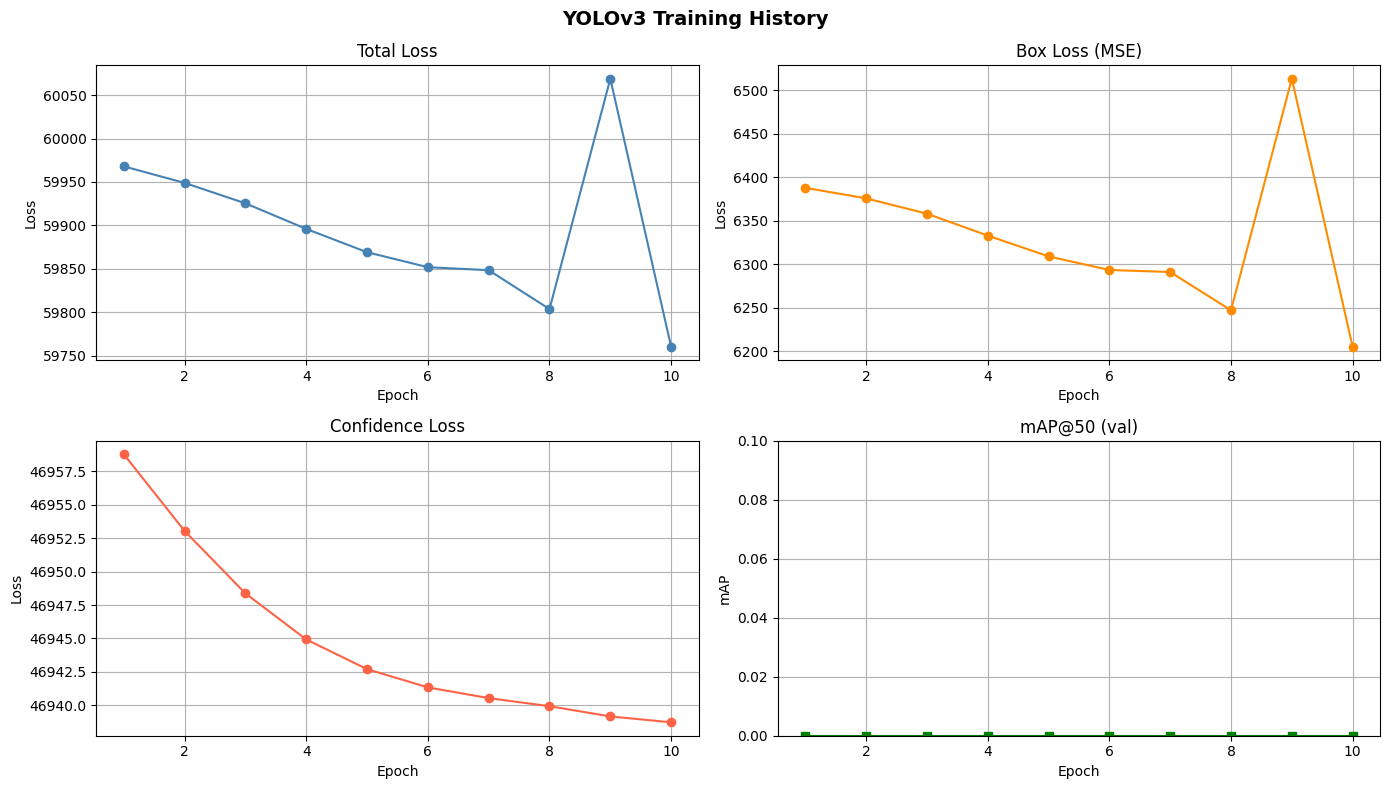

Best mAP@50: 0.0000 at epoch 1
Final Loss : 59760.0484


In [36]:
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, len(history["loss"]) + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("YOLOv3 Training History", fontsize=14, fontweight="bold")

# Total loss
axes[0,0].plot(epochs, history["loss"], marker="o", color="steelblue")
axes[0,0].set_title("Total Loss")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")
axes[0,0].grid(True)

# CIoU loss
axes[0,1].plot(epochs, history["box"], marker="o", color="darkorange")
axes[0,1].set_title("Box Loss (MSE)")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Loss")
axes[0,1].grid(True)

# Conf loss
axes[1,0].plot(epochs, history["conf"], marker="o", color="tomato")
axes[1,0].set_title("Confidence Loss")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Loss")
axes[1,0].grid(True)

# mAP@50
axes[1,1].plot(epochs, history["map50"], marker="s", color="green")
axes[1,1].set_title("mAP@50 (val)")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("mAP")
axes[1,1].set_ylim(0, max(max(history["map50"]) * 1.2, 0.1))
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best mAP@50: {max(history['map50']):.4f} at epoch {np.argmax(history['map50'])+1}")
print(f"Final Loss : {history['loss'][-1]:.4f}")


# Exercises

1. In the lab, we saw how the YOLOv3 Darknet configuration file could be parsed and mapped to PyTorch modules. Do the same for **YOLOv4**. Download `yolov4.cfg` from the [YOLOv4 GitHub repository](https://github.com/AlexeyAB/darknet) and modify `MyDarknet`, `darknet.py`, and `util.py` as necessary.

   Changes required:
   - Implement the **Mish** activation function
   - Add support for `maxpool` in `create_modules()` and `forward()`
   - Enable `[route]` to concatenate more than two previous layers
   - Load pretrained weights from the [YOLOv4 release](https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights)
   - Scale inputs to 608×608 in RGB order (not BGR)

2. Train the YOLOv4 model on the COCO dataset (or another dataset of your choice).

   a) Load ImageNet pretrained weights for CSPDarknet53 and initialize the backbone.

   b) Implement a `train_yolo()` function that:
      - Applies basic data augmentation
      - Converts anchor-relative outputs to bounding box coordinates
      - Computes loss (MSE for bbox + BCE for objectness/class)
      - Uses IoU thresholds to filter predictions

   c) Train for at least 5 epochs and verify the model is learning (loss decreasing).

   d) Compute **mAP** on the COCO validation set.

   e) Replace the standard IoU loss with **CIoU loss** and compare mAP:

   | Loss | mAP |
   |---|---|
   | MSE / IoU loss | ? |
   | CIoU loss | ? |

3. **Why is YOLO v3 faster than Faster R-CNN?** Explain the architectural difference that enables single-shot detection.

---

## Submission

Submit your work to GitHub. Your repository should contain:

### 1. Training Script (`run.py`)

```bash
# Inference with pretrained weights
python3 run.py --model yolov3 --weights yolov3.weights --image dog-cycle-car.png --infer

# Train on COCO
python3 run.py --model yolov4 --dataset coco --epochs 5 --train

# Evaluate mAP
python3 run.py --model yolov4 --weights yolov4.weights --dataset coco --evaluate
```

### 2. `README.md`

Your `README.md` must include:

**Commands used** (exact commands you ran)

**Results table:**

| Model | Dataset | mAP | Time/epoch | Notes |
|---|---|---|---|---|
| YOLOv3 (pretrained) | COCO | ? | — | inference only |
| YOLOv4 (IoU loss) | COCO | ? | ? | trained from scratch |
| YOLOv4 (CIoU loss) | COCO | ? | ? | loss comparison |

**Discussion** (3–5 sentences): What was the effect of CIoU vs standard loss? What challenges did you encounter training on COCO?